In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount('/content/drive')

csv_path = '/content/drive/MyDrive/AMES CRASH DATA.csv'
df = pd.read_csv(csv_path)

df.head()

Mounted at /content/drive


,X,Y,OBJECTID,CRASH_KEY,CASENUMBER,LECASENUM,CRASH_DATE,CRASH_MONTH,CRASH_DAY,TIMESTR,...,YCOORD,REST_UPDATED,REST_UPDATE_UTC_OFFSET,CRASH_DATETIME,CRASH_DATETIME_UTC,CRASH_DATETIME_UTC_OFFSET,CITY_NAME,COUNTY_NAME,CARDINAL,GLOBALID
0,-1.042104e+07,5.165010e+06,19533959,20231344988,20231344988,23000337,2023/01/26 00:00:00+00,1,5,13:59,...,4652945,2026/01/01 06:45:28+00,NaN,2023/01/26 13:59:00+00,NaN,NaN,AMES,STORY,1,{978134C1-6C8F-4E99-B374-77172B026F14}
1,-1.041802e+07,5.162411e+06,19533960,20231344989,20231344989,23000348,2023/01/27 00:00:00+00,1,6,04:47,...,4651004,2026/01/01 06:45:28+00,NaN,2023/01/27 04:47:00+00,NaN,NaN,AMES,STORY,1,{4E29FE00-E5EA-4956-86D4-18F3AE4DD97E}
2,-1.042309e+07,5.163412e+06,19533961,20231344987,20231344987,23000336,2023/01/26 00:00:00+00,1,5,10:58,...,4651773,2026/01/01 06:45:28+00,NaN,2023/01/26 10:58:00+00,NaN,NaN,AMES,STORY,3,{8F907997-D519-4569-9042-DA70FBEBB566}
3,-1.042061e+07,5.162005e+06,19533965,20231344991,20231344991,23000357,2023/01/27 00:00:00+00,1,6,16:34,...,4650716,2026/01/01 06:45:28+00,NaN,2023/01/27 16:34:00+00,NaN,NaN,AMES,STORY,1,{F49E7633-3AC1-4A79-B98D-A10F00C11F2F}
4,-1.042066e+07,5.164412e+06,19533966,20231344992,20231344992,23000367,2023/01/28 00:00:00+00,1,7,09:03,...,4652500,2026/01/01 06:45:28+00,NaN,2023/01/28 09:03:00+00,NaN,NaN,AMES,STORY,1,{0984E6E7-1BDE-49BE-9D93-C5DB0D2DFB33}


In [ ]:
df['CRASH_DATE'] = pd.to_datetime(df['CRASH_DATE'])
display(df['CRASH_DATE'].head())

,CRASH_DATE
0,2023-01-26 00:00:00+00:00
1,2023-01-27 00:00:00+00:00
2,2023-01-26 00:00:00+00:00
3,2023-01-27 00:00:00+00:00
4,2023-01-28 00:00:00+00:00


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_cols] = df[numerical_cols].astype(float)
display(df[numerical_cols].head())

,X,Y,OBJECTID,CRASH_KEY,CASENUMBER,CRASH_MONTH,CRASH_DAY,DISTRICT,COUNTY_NUMBER,CITY_NUMBER,...,PROPDMG,VEHICLES,TOCCUPANTS,REPORT,XCOORD,YCOORD,REST_UPDATE_UTC_OFFSET,CRASH_DATETIME_UTC,CRASH_DATETIME_UTC_OFFSET,CARDINAL
0,-1.042104e+07,5.165010e+06,19533959.0,2.023134e+10,2.023134e+10,1.0,5.0,1.0,85.0,155.0,...,6000.0,2.0,4.0,7.0,449190.0,4652945.0,NaN,NaN,NaN,1.0
1,-1.041802e+07,5.162411e+06,19533960.0,2.023134e+10,2.023134e+10,1.0,6.0,1.0,85.0,155.0,...,10500.0,2.0,2.0,7.0,451418.0,4651004.0,NaN,NaN,NaN,1.0
2,-1.042309e+07,5.163412e+06,19533961.0,2.023134e+10,2.023134e+10,1.0,5.0,1.0,85.0,155.0,...,5000.0,2.0,3.0,7.0,447659.0,4651773.0,NaN,NaN,NaN,3.0
3,-1.042061e+07,5.162005e+06,19533965.0,2.023134e+10,2.023134e+10,1.0,6.0,1.0,85.0,155.0,...,16266.0,2.0,2.0,7.0,449494.0,4650716.0,NaN,NaN,NaN,1.0
4,-1.042066e+07,5.164412e+06,19533966.0,2.023134e+10,2.023134e+10,1.0,7.0,1.0,85.0,155.0,...,3000.0,2.0,2.0,7.0,449468.0,4652500.0,NaN,NaN,NaN,1.0


In [ ]:
print(df.columns)

Index(['X', 'Y', 'OBJECTID', 'CRASH_KEY', 'CASENUMBER', 'LECASENUM',
       'CRASH_DATE', 'CRASH_MONTH', 'CRASH_DAY', 'TIMESTR', 'DISTRICT',
       'COUNTY_NUMBER', 'CITY_NUMBER', 'SYSTEMSTR', 'LITERAL', 'FRSTHARM',
       'LOCFSTHRM', 'CRCOMNNR', 'MAJCSE', 'DRUGALC', 'ECNTCRC', 'LIGHT',
       'CSRFCND', 'WEATHER', 'RCNTCRC', 'RDTYP', 'PAVED', 'WZRELATED', 'CSEV',
       'FATALITIES', 'INJURIES', 'MAJINJURY', 'MININJURY', 'POSSINJURY',
       'UNKINJURY', 'PROPDMG', 'VEHICLES', 'TOCCUPANTS', 'REPORT', 'XCOORD',
       'YCOORD', 'REST_UPDATED', 'REST_UPDATE_UTC_OFFSET', 'CRASH_DATETIME',
       'CRASH_DATETIME_UTC', 'CRASH_DATETIME_UTC_OFFSET', 'CITY_NAME',
       'COUNTY_NAME', 'CARDINAL', 'GLOBALID'],
      dtype='object')


In [ ]:
df['CITY_NUMBER'] = 155
df

,X,Y,OBJECTID,CRASH_KEY,CASENUMBER,LECASENUM,CRASH_DATE,CRASH_MONTH,CRASH_DAY,TIMESTR,...,YCOORD,REST_UPDATED,REST_UPDATE_UTC_OFFSET,CRASH_DATETIME,CRASH_DATETIME_UTC,CRASH_DATETIME_UTC_OFFSET,CITY_NAME,COUNTY_NAME,CARDINAL,GLOBALID
0,-1.042104e+07,5.165010e+06,19533959.0,2.023134e+10,2.023134e+10,23000337,2023-01-26 00:00:00+00:00,1.0,5.0,13:59,...,4652945.0,2026/01/01 06:45:28+00,NaN,2023/01/26 13:59:00+00,NaN,NaN,AMES,STORY,1.0,{978134C1-6C8F-4E99-B374-77172B026F14}
1,-1.041802e+07,5.162411e+06,19533960.0,2.023134e+10,2.023134e+10,23000348,2023-01-27 00:00:00+00:00,1.0,6.0,04:47,...,4651004.0,2026/01/01 06:45:28+00,NaN,2023/01/27 04:47:00+00,NaN,NaN,AMES,STORY,1.0,{4E29FE00-E5EA-4956-86D4-18F3AE4DD97E}
2,-1.042309e+07,5.163412e+06,19533961.0,2.023134e+10,2.023134e+10,23000336,2023-01-26 00:00:00+00:00,1.0,5.0,10:58,...,4651773.0,2026/01/01 06:45:28+00,NaN,2023/01/26 10:58:00+00,NaN,NaN,AMES,STORY,3.0,{8F907997-D519-4569-9042-DA70FBEBB566}
3,-1.042061e+07,5.162005e+06,19533965.0,2.023134e+10,2.023134e+10,23000357,2023-01-27 00:00:00+00:00,1.0,6.0,16:34,...,4650716.0,2026/01/01 06:45:28+00,NaN,2023/01/27 16:34:00+00,NaN,NaN,AMES,STORY,1.0,{F49E7633-3AC1-4A79-B98D-A10F00C11F2F}
4,-1.042066e+07,5.164412e+06,19533966.0,2.023134e+10,2.023134e+10,23000367,2023-01-28 00:00:00+00:00,1.0,7.0,09:03,...,4652500.0,2026/01/01 06:45:28+00,NaN,2023/01/28 09:03:00+00,NaN,NaN,AMES,STORY,1.0,{0984E6E7-1BDE-49BE-9D93-C5DB0D2DFB33}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3729,-1.042827e+07,5.164130e+06,21256289.0,2.024146e+10,2.024146e+10,24004690,2024-12-24 00:00:00+00:00,12.0,3.0,13:36,...,4652334.0,2026/04/11 09:09:54+00,NaN,2024/12/24 13:36:00+00,NaN,NaN,AMES,STORY,1.0,{975AAB34-72B0-4133-A23A-79EA0B8F01D8}
3730,-1.042609e+07,5.164374e+06,21256290.0,2.024146e+10,2.024146e+10,24004766,2024-12-29 00:00:00+00:00,12.0,1.0,03:42,...,4652503.0,2026/04/11 09:09:54+00,NaN,2024/12/29 03:42:00+00,NaN,NaN,AMES,STORY,1.0,{16221819-012A-4E58-9596-B9AFB360F04E}
3731,-1.042638e+07,5.161994e+06,21256426.0,2.024146e+10,2.024146e+10,24004673,2024-12-22 00:00:00+00:00,12.0,1.0,19:54,...,4650740.0,2026/04/11 09:09:54+00,NaN,2024/12/22 19:54:00+00,NaN,NaN,AMES,STORY,3.0,{914940E3-B4E0-4D9E-8470-D2888B8F9E0F}
3732,-1.042500e+07,5.166253e+06,21256539.0,2.024146e+10,2.024146e+10,2024027226,2024-10-31 00:00:00+00:00,10.0,5.0,23:57,...,4653889.0,2026/04/11 09:09:54+00,NaN,2024/10/31 23:57:00+00,NaN,NaN,AMES,STORY,4.0,{51839EF1-C260-49C6-90DE-CE068361BF12}


In [ ]:
# Should see all 7 days represented
print(df['CRASH_DAY'].value_counts())

# Pick any Saturday and confirm Thu/Fri/Sat share a YearWeek
sample = df[df['CRASH_DATE'].between('2024-10-03', '2024-10-05')][['CRASH_DATE', 'CRASH_DAY']].drop_duplicates()
print(sample)


CRASH_DAY
6.0    647
5.0    628
4.0    583
3.0    549
2.0    514
7.0    477
1.0    336
Name: count, dtype: int64
                    CRASH_DATE  CRASH_DAY
3391 2024-10-05 00:00:00+00:00        7.0
3400 2024-10-03 00:00:00+00:00        5.0
3401 2024-10-04 00:00:00+00:00        6.0


In [ ]:
games = pd.DataFrame([
    # Columns
    # Date----------Opponent--------------------Time---CyHawk---Conf

    # --- 2022 ---
   ("2022-09-03", "Southeast Missouri State", "~14:00", False, False),
    ("2022-09-17", "Ohio",                     "~14:00", False, False),
    ("2022-09-24", "Baylor",                   "~14:00", False, True),   # Big 12
    ("2022-10-08", "Kansas State",             "~14:00", False, True),   # Farmageddon
    ("2022-10-29", "Oklahoma",                 "~14:00", False, True),
    ("2022-11-05", "West Virginia",            "~14:00", False, True),
    ("2022-11-19", "Texas Tech",               "~14:00", False, True),

    # --- 2023 ---
    ("2023-09-02", "Northern Iowa",            "13:00",  False, False),
    ("2023-09-09", "Iowa",                     "14:30",  True,  False),  # Cy-Hawk!
    ("2023-09-23", "Oklahoma State",           "~14:00", False, True),
    ("2023-10-07", "TCU",                      "19:00",  False, True),
    ("2023-11-04", "Kansas",                   "~14:00", False, True),
    ("2023-11-18", "Texas",                    "19:00",  False, True),

    # --- 2024 ---
    ("2024-08-31", "North Dakota",             "14:30",  False, False),
    ("2024-09-14", "Arkansas State",           "~14:00", False, False),
    ("2024-09-28", "Baylor",                   "18:36",  False, True),
    ("2024-10-19", "UCF",                      "18:30",  False, True),
    ("2024-11-02", "Texas Tech",               "~14:00", False, True),
    ("2024-11-16", "Cincinnati",               "~14:00", False, True),
    ("2024-11-30", "Kansas State",             "18:30",  False, True),   # Farmageddon

    # --- 2025 ---
    ("2025-08-30", "South Dakota",             "~14:00", False, False),
    ("2025-09-06", "Iowa",                     "11:00",  True,  False),  # Cy-Hawk!
    ("2025-09-27", "Arizona",                  "18:00",  False, True),
    ("2025-10-25", "BYU",                      "14:30",  False, True),   # Homecoming
    ("2025-11-01", "Arizona State",            "12:00",  False, True),
    ("2025-11-22", "TCU",                      "~14:00", False, True),
], columns=["Date", "opponent", "kickoff", "is_cyhawk", "is_conference"])

games["Date"] = pd.to_datetime(games["Date"])
games["is_home"] = True
games["kickoff_clean"] = games["kickoff"].str.replace("~", "", regex=False)
games["kickoff_hr"] = pd.to_datetime(games["kickoff_clean"], format="%H:%M").dt.hour
games["kickoff_min"] = pd.to_datetime(games["kickoff_clean"], format="%H:%M").dt.minute
games["game_type"] = np.where(games["kickoff_hr"] < 17, "Early", "Night")
games["YearWeek"] = games["Date"].dt.to_period("W-SUN")

display(games.head())

,Date,opponent,kickoff,is_cyhawk,is_conference,is_home,kickoff_clean,kickoff_hr,kickoff_min,game_type,YearWeek
0,2022-09-03,Southeast Missouri State,~14:00,False,False,True,14:00,14,0,Early,2022-08-29/2022-09-04
1,2022-09-17,Ohio,~14:00,False,False,True,14:00,14,0,Early,2022-09-12/2022-09-18
2,2022-09-24,Baylor,~14:00,False,True,True,14:00,14,0,Early,2022-09-19/2022-09-25
3,2022-10-08,Kansas State,~14:00,False,True,True,14:00,14,0,Early,2022-10-03/2022-10-09
4,2022-10-29,Oklahoma,~14:00,False,True,True,14:00,14,0,Early,2022-10-24/2022-10-30


In [ ]:
print("Games per season:")
print(games["Date"].dt.year.value_counts().sort_index())

print("\nGame type distribution:")
print(games["game_type"].value_counts())

print("\nCy-Hawk home games (should be 2: 2023 and 2025):")
print(games[games["is_cyhawk"]][["Date", "opponent", "kickoff", "game_type"]])

print("\nFull calendar:")
print(games[["Date", "opponent", "kickoff", "game_type", "is_cyhawk"]]
      .to_string(index=False))

Games per season:
Date
2022    7
2023    6
2024    7
2025    6
Name: count, dtype: int64

Game type distribution:
game_type
Early    20
Night     6
Name: count, dtype: int64

Cy-Hawk home games (should be 2: 2023 and 2025):
         Date opponent kickoff game_type
8  2023-09-09     Iowa   14:30     Early
21 2025-09-06     Iowa   11:00     Early

Full calendar:
      Date                 opponent kickoff game_type  is_cyhawk
2022-09-03 Southeast Missouri State  ~14:00     Early      False
2022-09-17                     Ohio  ~14:00     Early      False
2022-09-24                   Baylor  ~14:00     Early      False
2022-10-08             Kansas State  ~14:00     Early      False
2022-10-29                 Oklahoma  ~14:00     Early      False
2022-11-05            West Virginia  ~14:00     Early      False
2022-11-19               Texas Tech  ~14:00     Early      False
2023-09-02            Northern Iowa   13:00     Early      False
2023-09-09                     Iowa   14:30     Earl

In [ ]:
games_to_merge = games[["YearWeek", "opponent", "kickoff_hr",
                        "game_type", "is_cyhawk", "is_conference"]].copy()

df["YearWeek"] = df["CRASH_DATE"].dt.to_period("W-SUN")
df_merged = df.merge(games_to_merge, on="YearWeek", how="left")
# Weeks with no home game = "Control"
df_merged["WeekType"] = df_merged["game_type"].fillna("Control")
df_merged["is_game_week"] = df_merged["game_type"].notna()
df_merged["is_cyhawk"] = df_merged["is_cyhawk"].fillna(False)
df_merged["is_conference"] = df_merged["is_conference"].fillna(False)

/tmp/ipykernel_4740/1648030464.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["YearWeek"] = df["CRASH_DATE"].dt.to_period("W-SUN")
/tmp/ipykernel_4740/1648030464.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged["is_cyhawk"] = df_merged["is_cyhawk"].fillna(False)
/tmp/ipykernel_4740/1648030464.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged["is_conference"] = df_merged["is_conference"].fillna(False)


In [ ]:
print("Row count before/after merge:")
print(f"  Before: {len(df):,}")
print(f"  After:  {len(df_merged):,}")
print(f"  Match:  {len(df) == len(df_merged)}")

print("\nWeekType distribution (transactions):")
print(df_merged["WeekType"].value_counts())

print("\nUnique weeks by type:")
print(df_merged.groupby("WeekType")["YearWeek"].nunique())

print("\nGame-week transactions by day of week:")
print(pd.crosstab(df_merged["CRASH_DAY"], df_merged["WeekType"]))

Row count before/after merge:
  Before: 3,734
  After:  3,734
  Match:  True

WeekType distribution (transactions):
WeekType
Control    3108
Early       500
Night       126
Name: count, dtype: int64

Unique weeks by type:
WeekType
Control    183
Early       20
Night        6
Name: YearWeek, dtype: int64

Game-week transactions by day of week:
WeekType   Control  Early  Night
CRASH_DAY                       
1.0            276     41     19
2.0            435     62     17
3.0            466     72     11
4.0            488     76     19
5.0            544     75      9
6.0            536     81     30
7.0            363     93     21


In [ ]:
check = df_merged[(df_merged["CRASH_DATE"] >= "2023-09-04") &
                  (df_merged["CRASH_DATE"] <= "2023-09-10")][
                  ["CRASH_DATE", "CRASH_DAY", "WeekType", "opponent", "is_cyhawk"]
                  ].drop_duplicates()
print(check.sort_values("CRASH_DATE"))

                   CRASH_DATE  CRASH_DAY WeekType opponent  is_cyhawk
573 2023-09-04 00:00:00+00:00        2.0    Early     Iowa       True
574 2023-09-05 00:00:00+00:00        3.0    Early     Iowa       True
527 2023-09-06 00:00:00+00:00        4.0    Early     Iowa       True
562 2023-09-07 00:00:00+00:00        5.0    Early     Iowa       True
591 2023-09-08 00:00:00+00:00        6.0    Early     Iowa       True
564 2023-09-09 00:00:00+00:00        7.0    Early     Iowa       True
596 2023-09-10 00:00:00+00:00        1.0    Early     Iowa       True


In [ ]:
df_merged["Month"] = df_merged["CRASH_DATE"].dt.month
# Create a 'DayOfWeek' column from 'CRASH_DATE'
df_merged["DayOfWeek"] = df_merged["CRASH_DATE"].dt.day_name()
season = df_merged[df_merged["Month"].between(8, 12)].copy()

# One row per date
daily = (season
         .groupby(["CRASH_DATE", "DayOfWeek", "WeekType"], as_index=False)
         .agg(total_crashes=("OBJECTID", "count")))

# Mean crashes per (day-of-week, week-type) cell
cells = (daily
         .groupby(["DayOfWeek", "WeekType"], as_index=False)
         .agg(mean_crashes=("total_crashes", "mean"),
              n_days=("total_crashes", "size")))
# Order the days of week
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]
cells["DayOfWeek"] = pd.Categorical(cells["DayOfWeek"],
                                    categories=dow_order, ordered=True)
cells = cells.sort_values("DayOfWeek")

# Quick look at the numbers
pivot = cells.pivot_table(index="DayOfWeek", columns="WeekType",
                          values="mean_crashes").reindex(dow_order).fillna(0)
print("Mean daily crashes:")
print(pivot.round(0))

Mean daily crashes:
WeekType   Control  Early  Night
DayOfWeek                       
Monday         3.0    3.0    3.0
Tuesday        3.0    4.0    3.0
Wednesday      3.0    4.0    4.0
Thursday       4.0    4.0    2.0
Friday         4.0    4.0    5.0
Saturday       3.0    5.0    4.0
Sunday         2.0    2.0    3.0


/tmp/ipykernel_4740/145706776.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = cells.pivot_table(index="DayOfWeek", columns="WeekType",


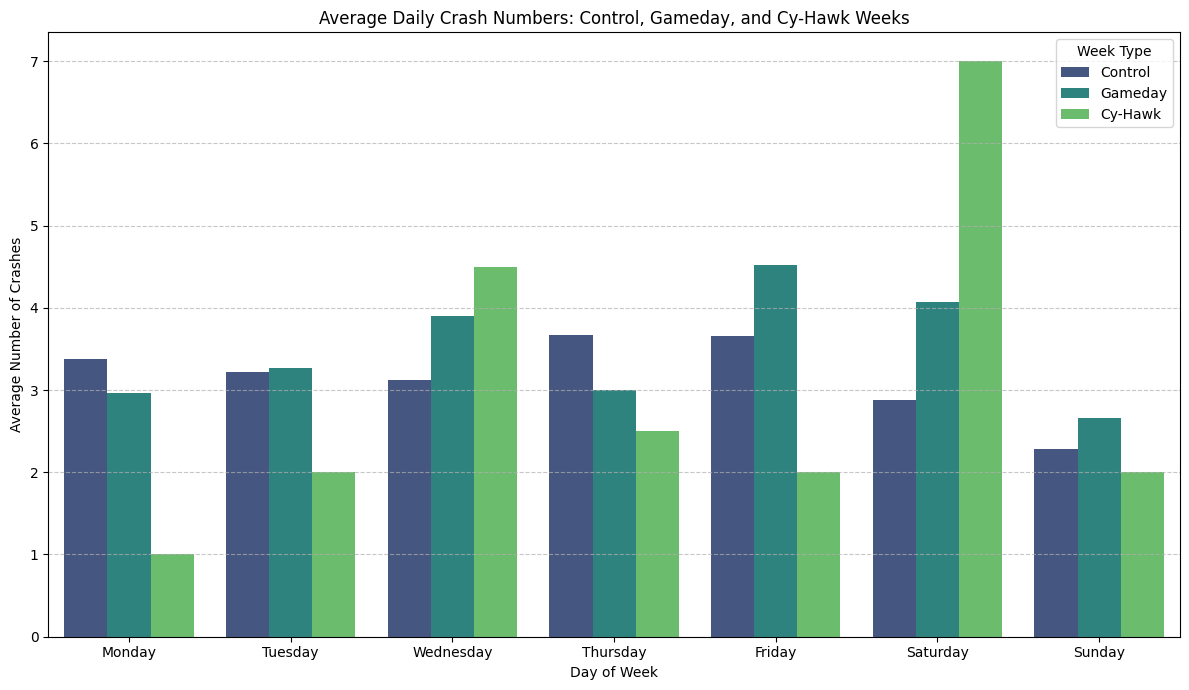

In [ ]:
# Calculate Gameday average (average of Early and Night game weeks) from the pivot table
pivot['Gameday'] = pivot[['Early', 'Night']].mean(axis=1)

# Calculate mean crashes specifically for Cy-Hawk game days
cyhawk_crashes = (df_merged[df_merged['is_cyhawk'] == True]
                  .groupby(['CRASH_DATE', 'DayOfWeek'], as_index=False)
                  .agg(total_crashes=('OBJECTID', 'count')))

cyhawk_mean_crashes = (cyhawk_crashes
                       .groupby('DayOfWeek', as_index=False)
                       .agg(mean_crashes=('total_crashes', 'mean')))

# Order the days of week for cyhawk_mean_crashes to match the other data
cyhawk_mean_crashes['DayOfWeek'] = pd.Categorical(cyhawk_mean_crashes['DayOfWeek'],
                                                categories=dow_order, ordered=True)
cyhawk_mean_crashes = cyhawk_mean_crashes.sort_values('DayOfWeek')

# Add Cy-Hawk data to the pivot table, reindexing to ensure correct alignment
pivot['Cy-Hawk'] = cyhawk_mean_crashes.set_index('DayOfWeek')['mean_crashes'].reindex(dow_order).fillna(0)

# Select the relevant columns for plotting
plot_df = pivot[['Control', 'Gameday', 'Cy-Hawk']].copy()

# Reset index to make DayOfWeek a regular column for easier plotting with seaborn
plot_df = plot_df.reset_index()

# Melt the DataFrame to long format for easier bar plot creation
plot_df_melted = plot_df.melt(id_vars='DayOfWeek', var_name='WeekType_Category', value_name='Average_Crashes')

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(12, 7))
sns.barplot(data=plot_df_melted, x='DayOfWeek', y='Average_Crashes', hue='WeekType_Category', palette='viridis')
plt.title('Average Daily Crash Numbers: Control, Gameday, and Cy-Hawk Weeks')
plt.xlabel('Day of Week')
plt.ylabel('Average Number of Crashes')
plt.legend(title='Week Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4740/4060894187.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  injuries_pivot = injuries_cells.pivot_table(index="DayOfWeek", columns="WeekType",


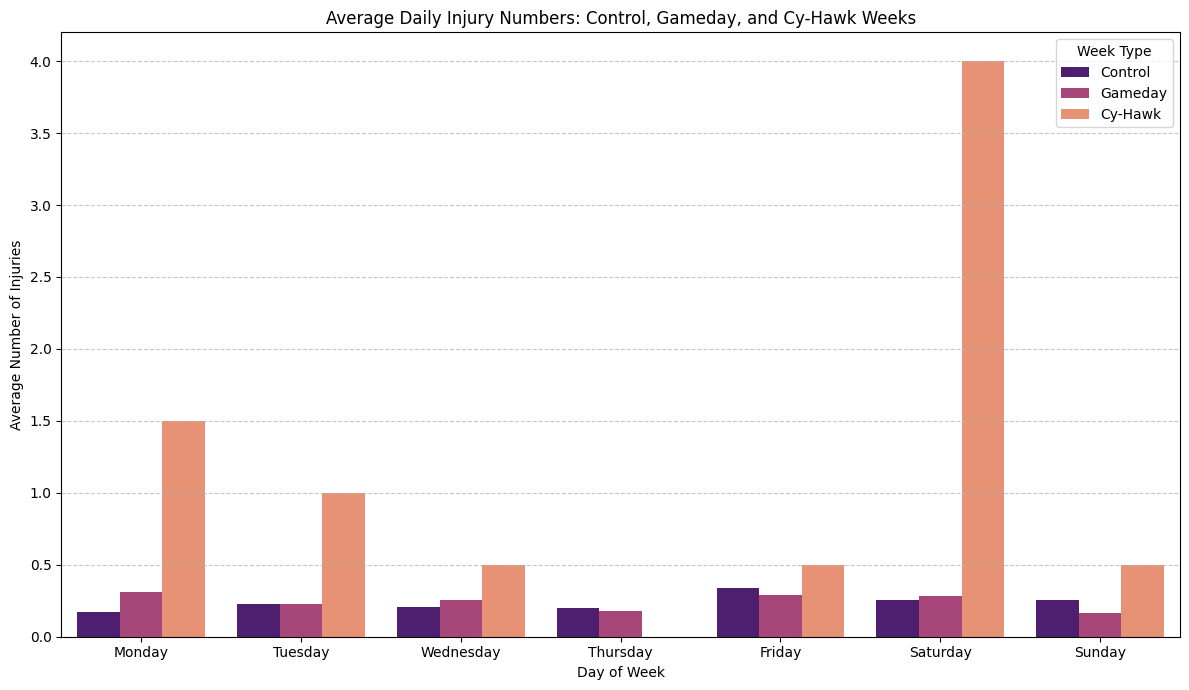

In [ ]:
# Calculate mean injuries per (day-of-week, week-type) cell
# Using the 'season' DataFrame (filtered for months 8-12)
injuries_cells = (season
                  .groupby(["DayOfWeek", "WeekType"], as_index=False)
                  .agg(mean_injuries=("INJURIES", "mean"),
                       n_days=("OBJECTID", "count")))

# Order the days of week
injuries_cells["DayOfWeek"] = pd.Categorical(injuries_cells["DayOfWeek"],
                                            categories=dow_order, ordered=True)
injuries_cells = injuries_cells.sort_values("DayOfWeek")

# Create a pivot table for mean injuries
injuries_pivot = injuries_cells.pivot_table(index="DayOfWeek", columns="WeekType",
                                            values="mean_injuries").reindex(dow_order).fillna(0)

# Calculate Gameday average for injuries
injuries_pivot['Gameday'] = injuries_pivot[['Early', 'Night']].mean(axis=1)

# Calculate mean injuries specifically for Cy-Hawk game days
cyhawk_injuries = (df_merged[df_merged['is_cyhawk'] == True]
                     .groupby(['CRASH_DATE', 'DayOfWeek'], as_index=False)
                     .agg(total_injuries=('INJURIES', 'sum')))

cyhawk_mean_injuries = (cyhawk_injuries
                            .groupby('DayOfWeek', as_index=False)
                            .agg(mean_injuries=('total_injuries', 'mean')))

# Order the days of week for cyhawk_mean_injuries
cyhawk_mean_injuries['DayOfWeek'] = pd.Categorical(cyhawk_mean_injuries['DayOfWeek'],
                                                categories=dow_order, ordered=True)
cyhawk_mean_injuries = cyhawk_mean_injuries.sort_values('DayOfWeek')

# Add Cy-Hawk injury data to the pivot table
injuries_pivot['Cy-Hawk'] = cyhawk_mean_injuries.set_index('DayOfWeek')['mean_injuries'].reindex(dow_order).fillna(0)

# Select the relevant columns for plotting injuries
plot_injuries_df = injuries_pivot[['Control', 'Gameday', 'Cy-Hawk']].copy()

# Reset index and melt for plotting
plot_injuries_df_melted = plot_injuries_df.reset_index().melt(id_vars='DayOfWeek',
                                                            var_name='WeekType_Category',
                                                            value_name='Average_Injuries')

# Plotting injuries
fig_injuries = plt.figure(figsize=(12, 7))
sns.barplot(data=plot_injuries_df_melted, x='DayOfWeek', y='Average_Injuries', hue='WeekType_Category', palette='magma')
plt.title('Average Daily Injury Numbers: Control, Gameday, and Cy-Hawk Weeks')
plt.xlabel('Day of Week')
plt.ylabel('Average Number of Injuries')
plt.legend(title='Week Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

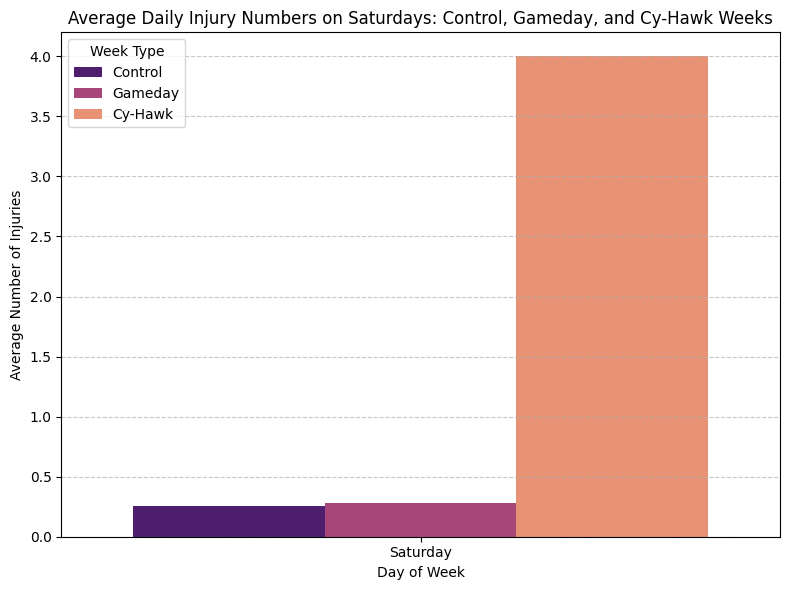

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for only Saturday data
saturday_injuries_df_melted = plot_injuries_df_melted[plot_injuries_df_melted['DayOfWeek'] == 'Saturday']

# Plotting injuries for Saturday only
fig_saturday_injuries = plt.figure(figsize=(8, 6))
sns.barplot(data=saturday_injuries_df_melted, x='DayOfWeek', y='Average_Injuries', hue='WeekType_Category', palette='magma')
plt.title('Average Daily Injury Numbers on Saturdays: Control, Gameday, and Cy-Hawk Weeks')
plt.xlabel('Day of Week')
plt.ylabel('Average Number of Injuries')
plt.legend(title='Week Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

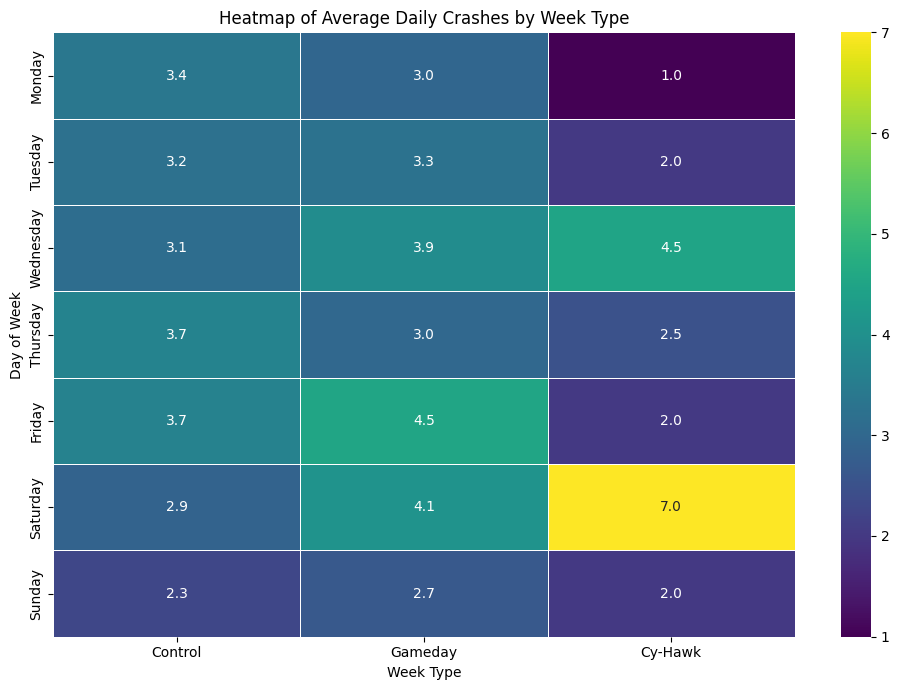

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a heatmap for average daily crashes
plt.figure(figsize=(10, 7))
sns.heatmap(pivot[['Control', 'Gameday', 'Cy-Hawk']], annot=True, cmap='viridis', fmt=".1f", linewidths=.5)
plt.title('Heatmap of Average Daily Crashes by Week Type')
plt.xlabel('Week Type')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

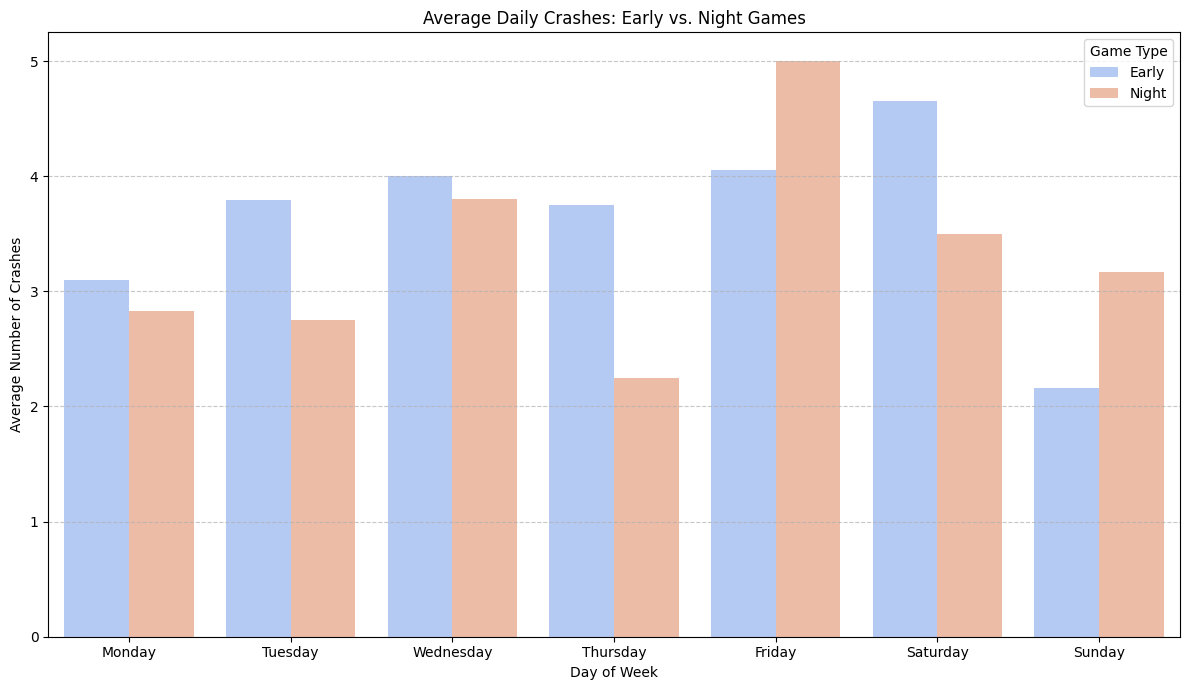

In [ ]:
# Select 'Early' and 'Night' game data from the pivot table
day_night_crashes = pivot[['Early', 'Night']].copy()

# Reset index to make DayOfWeek a regular column for easier plotting
day_night_crashes = day_night_crashes.reset_index()

# Melt the DataFrame to long format for easier bar plot creation
day_night_crashes_melted = day_night_crashes.melt(id_vars='DayOfWeek',
                                                  var_name='Game_Time_Category',
                                                  value_name='Average_Crashes')

# Plotting
plt.figure(figsize=(12, 7))
sns.barplot(data=day_night_crashes_melted,
            x='DayOfWeek',
            y='Average_Crashes',
            hue='Game_Time_Category',
            palette='coolwarm')
plt.title('Average Daily Crashes: Early vs. Night Games')
plt.xlabel('Day of Week')
plt.ylabel('Average Number of Crashes')
plt.legend(title='Game Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

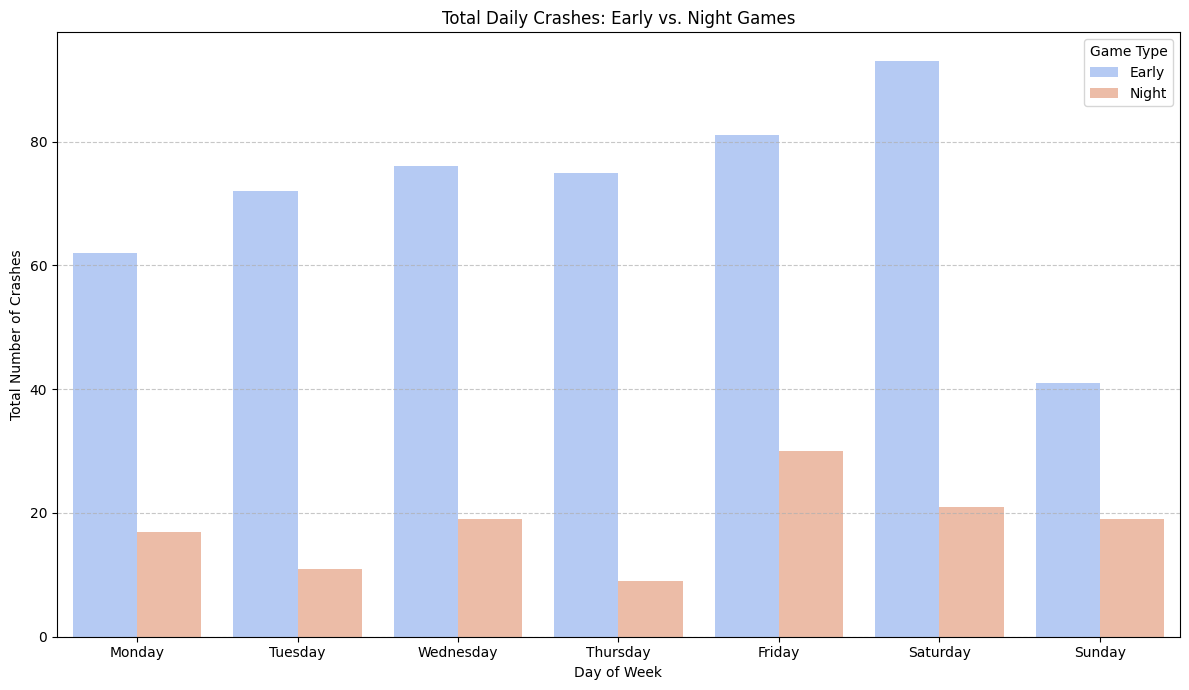

In [ ]:
# Calculate total crashes for 'Early' and 'Night' game weeks
total_crashes_by_gametype = (season[season['WeekType'].isin(['Early', 'Night'])]
                             .groupby(['DayOfWeek', 'WeekType'], as_index=False)
                             .agg(Total_Crashes=('OBJECTID', 'count')))

# Order the days of week for consistent plotting
total_crashes_by_gametype['DayOfWeek'] = pd.Categorical(total_crashes_by_gametype['DayOfWeek'],
                                                        categories=dow_order, ordered=True)
total_crashes_by_gametype = total_crashes_by_gametype.sort_values('DayOfWeek')

# Plotting total crashes
plt.figure(figsize=(12, 7))
sns.barplot(data=total_crashes_by_gametype,
            x='DayOfWeek',
            y='Total_Crashes',
            hue='WeekType',
            palette='coolwarm')
plt.title('Total Daily Crashes: Early vs. Night Games')
plt.xlabel('Day of Week')
plt.ylabel('Total Number of Crashes')
plt.legend(title='Game Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

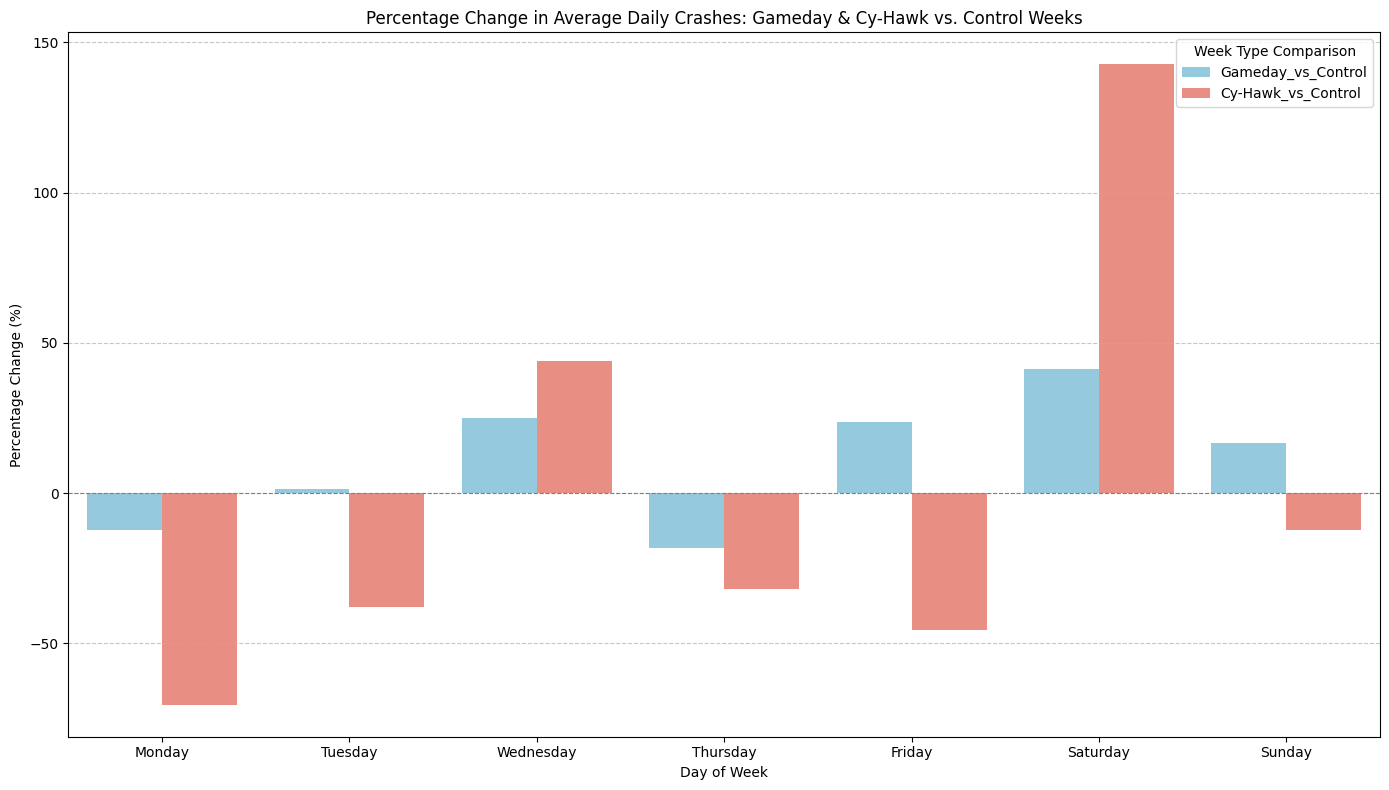

In [ ]:
# Calculate percentage change in crashes compared to Control weeks
plot_df_percentage = plot_df.copy()
plot_df_percentage['Gameday_vs_Control'] = ((plot_df_percentage['Gameday'] - plot_df_percentage['Control']) / plot_df_percentage['Control']) * 100
plot_df_percentage['Cy-Hawk_vs_Control'] = ((plot_df_percentage['Cy-Hawk'] - plot_df_percentage['Control']) / plot_df_percentage['Control']) * 100

# Select the relevant percentage change columns and melt for plotting
plot_df_percentage_melted = plot_df_percentage[['DayOfWeek', 'Gameday_vs_Control', 'Cy-Hawk_vs_Control']].melt(id_vars='DayOfWeek',
                                                                                                              var_name='Comparison_Type',
                                                                                                              value_name='Percentage_Change_in_Crashes')

# Plotting the percentage change
plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df_percentage_melted,
            x='DayOfWeek',
            y='Percentage_Change_in_Crashes',
            hue='Comparison_Type',
            palette={'Gameday_vs_Control': 'skyblue', 'Cy-Hawk_vs_Control': 'salmon'})
plt.title('Percentage Change in Average Daily Crashes: Gameday & Cy-Hawk vs. Control Weeks')
plt.xlabel('Day of Week')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a line at 0 for reference
plt.legend(title='Week Type Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

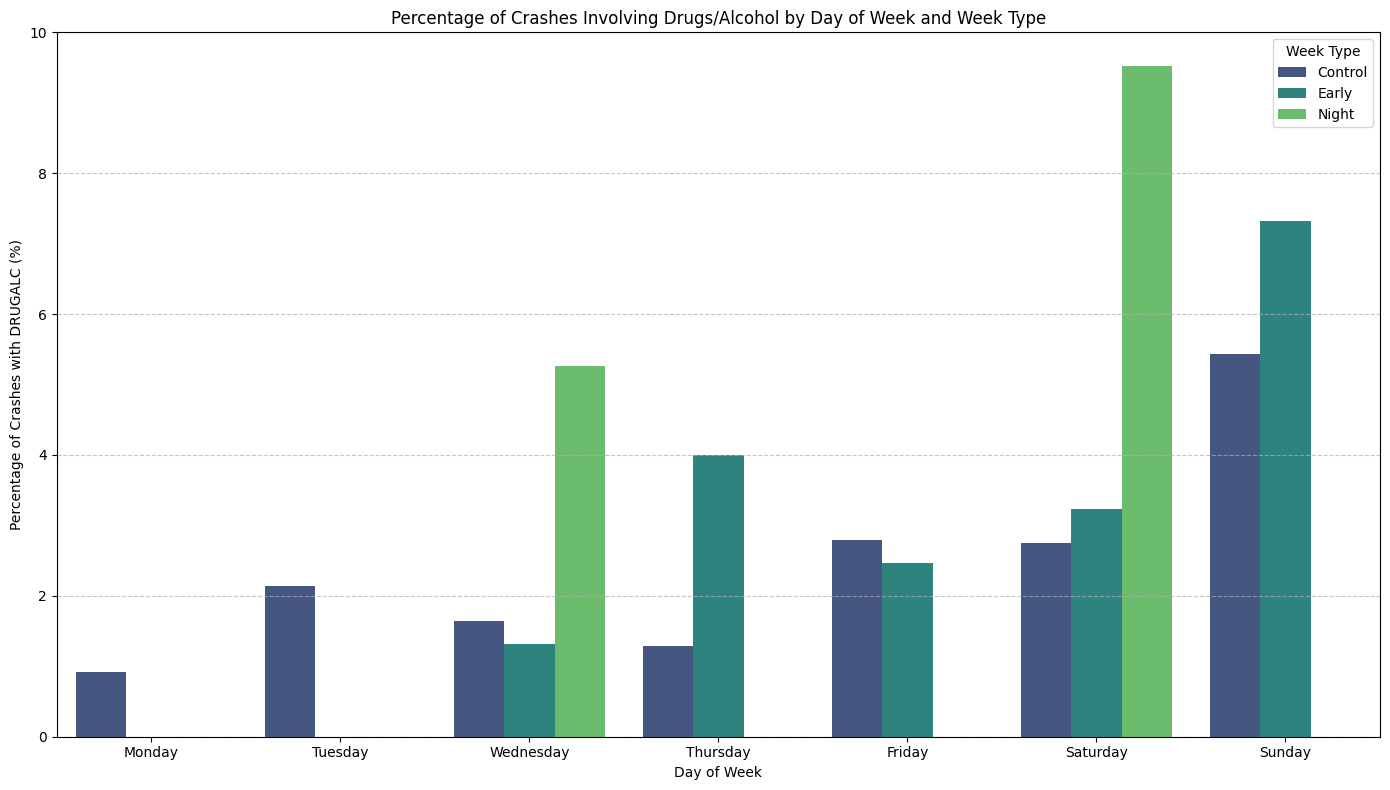

In [ ]:
# Calculate crashes with DRUGALC involvement, excluding the code for 'no involvement' (assuming 8.0)
drugalc_crashes = df_merged[df_merged['DRUGALC'] != 8.0].copy()

# Group by DayOfWeek and WeekType for drug/alcohol involved crashes
drugalc_counts = (drugalc_crashes
                  .groupby(['DayOfWeek', 'WeekType'], as_index=False)
                  .agg(DRUGALC_Crashes=('OBJECTID', 'count')))

# Group by DayOfWeek and WeekType for total crashes
total_crashes_by_type_day = (df_merged
                             .groupby(['DayOfWeek', 'WeekType'], as_index=False)
                             .agg(Total_Crashes=('OBJECTID', 'count')))

# Merge drugalc_counts with total_crashes_by_type_day
merged_counts = pd.merge(total_crashes_by_type_day, drugalc_counts,
                         on=['DayOfWeek', 'WeekType'], how='left').fillna(0)

# Calculate the percentage of crashes involving drugs/alcohol
merged_counts['DRUGALC_Percentage'] = (merged_counts['DRUGALC_Crashes'] / merged_counts['Total_Crashes']) * 100

# Order the days of week for consistent plotting
merged_counts["DayOfWeek"] = pd.Categorical(merged_counts["DayOfWeek"],
                                    categories=dow_order, ordered=True)
merged_counts = merged_counts.sort_values("DayOfWeek")

custom_palette = {'Control': 'gray', 'Early': 'red', 'Night': 'gold'}

# Plotting the percentage of DRUGALC involved crashes
plt.figure(figsize=(14, 8))
sns.barplot(data=merged_counts,
            x='DayOfWeek',
            y='DRUGALC_Percentage',
            hue='WeekType',
            palette='viridis')
plt.title('Percentage of Crashes Involving Drugs/Alcohol by Day of Week and Week Type')
plt.xlabel('Day of Week')
plt.ylabel('Percentage of Crashes with DRUGALC (%)')
plt.legend(title='Week Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4740/1816222263.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  prop_damage_pivot = prop_damage_cells.pivot_table(index="DayOfWeek", columns="WeekType",


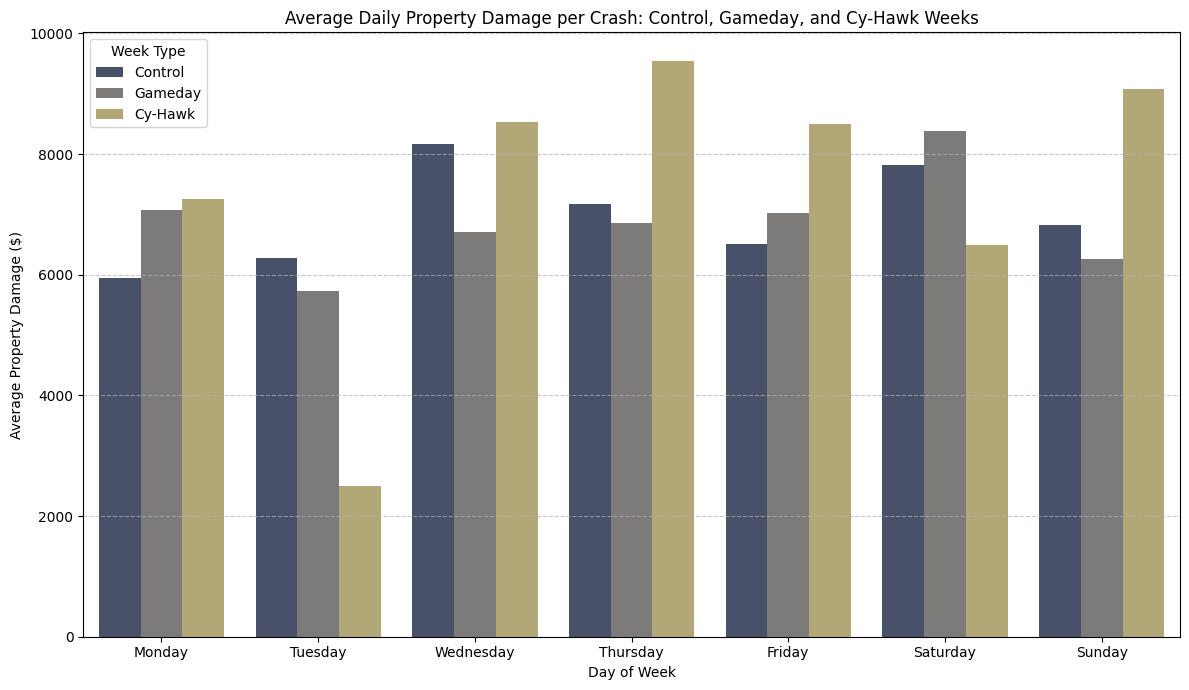

In [ ]:
# Calculate mean property damage per (day-of-week, week-type) cell
prop_damage_cells = (season
                     .groupby(["DayOfWeek", "WeekType"], as_index=False)
                     .agg(mean_prop_damage=("PROPDMG", "mean"),
                          n_crashes=("OBJECTID", "count")))

# Order the days of week
prop_damage_cells["DayOfWeek"] = pd.Categorical(prop_damage_cells["DayOfWeek"],
                                            categories=dow_order, ordered=True)
prop_damage_cells = prop_damage_cells.sort_values("DayOfWeek")

# Create a pivot table for mean property damage
prop_damage_pivot = prop_damage_cells.pivot_table(index="DayOfWeek", columns="WeekType",
                                                   values="mean_prop_damage").reindex(dow_order).fillna(0)

# Calculate Gameday average for property damage
prop_damage_pivot['Gameday'] = prop_damage_pivot[['Early', 'Night']].mean(axis=1)

# Calculate mean property damage specifically for Cy-Hawk game days
cyhawk_prop_damage = (df_merged[df_merged['is_cyhawk'] == True]
                        .groupby(['CRASH_DATE', 'DayOfWeek'], as_index=False)
                        .agg(total_prop_damage=('PROPDMG', 'sum')))

# Calculate average property damage from the sums, considering the number of crashes on those days
# Re-calculate mean crashes for Cy-Hawk days to get accurate per-crash average
cyhawk_crashes_count = (df_merged[df_merged['is_cyhawk'] == True]
                        .groupby(['CRASH_DATE', 'DayOfWeek'], as_index=False)
                        .agg(count_crashes=('OBJECTID', 'count')))

cyhawk_prop_damage_merged = pd.merge(cyhawk_prop_damage, cyhawk_crashes_count, on=['CRASH_DATE', 'DayOfWeek'], how='left')
cyhawk_prop_damage_merged['mean_prop_damage'] = cyhawk_prop_damage_merged['total_prop_damage'] / cyhawk_prop_damage_merged['count_crashes']

cyhawk_mean_prop_damage = (cyhawk_prop_damage_merged
                                .groupby('DayOfWeek', as_index=False)
                                .agg(mean_prop_damage=('mean_prop_damage', 'mean')))

# Order the days of week for cyhawk_mean_prop_damage
cyhawk_mean_prop_damage['DayOfWeek'] = pd.Categorical(cyhawk_mean_prop_damage['DayOfWeek'],
                                                categories=dow_order, ordered=True)
cyhawk_mean_prop_damage = cyhawk_mean_prop_damage.sort_values('DayOfWeek')

# Add Cy-Hawk property damage data to the pivot table
prop_damage_pivot['Cy-Hawk'] = cyhawk_mean_prop_damage.set_index('DayOfWeek')['mean_prop_damage'].reindex(dow_order).fillna(0)

# Select the relevant columns for plotting property damage
plot_prop_damage_df = prop_damage_pivot[['Control', 'Gameday', 'Cy-Hawk']].copy()

# Reset index and melt for plotting
plot_prop_damage_df_melted = plot_prop_damage_df.reset_index().melt(id_vars='DayOfWeek',
                                                            var_name='WeekType_Category',
                                                            value_name='Average_Property_Damage')

# Plotting property damage
fig_prop_damage = plt.figure(figsize=(12, 7))
sns.barplot(data=plot_prop_damage_df_melted, x='DayOfWeek', y='Average_Property_Damage', hue='WeekType_Category', palette='cividis')
plt.title('Average Daily Property Damage per Crash: Control, Gameday, and Cy-Hawk Weeks')
plt.xlabel('Day of Week')
plt.ylabel('Average Property Damage ($)')
plt.legend(title='Week Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

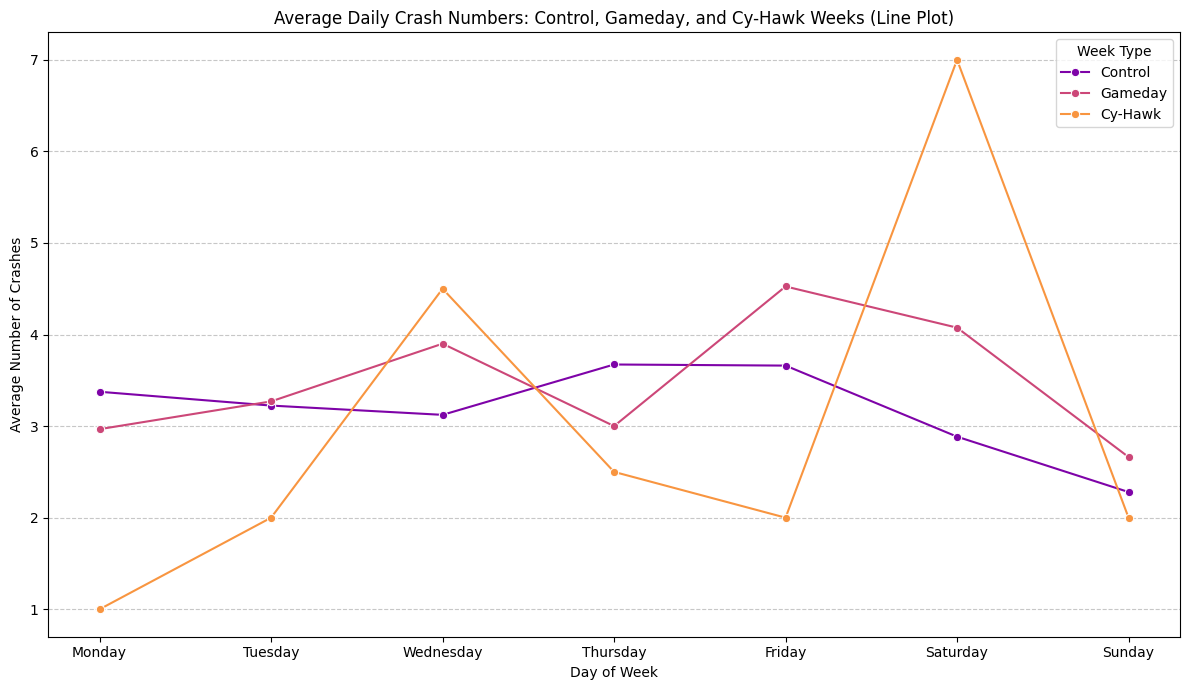

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# The plot_df DataFrame already contains 'Control', 'Gameday', and 'Cy-Hawk' average crashes by DayOfWeek
# Reset index to make DayOfWeek a regular column for easier plotting with seaborn
plot_df_line = plot_df.copy()
plot_df_line = plot_df_line.reset_index()
# Drop the 'index' column that was created by reset_index()
plot_df_line = plot_df_line.drop(columns=['index'])

# Melt the DataFrame to long format for easier line plot creation
plot_df_line_melted = plot_df_line.melt(id_vars='DayOfWeek', var_name='WeekType_Category', value_name='Average_Crashes')

# Plotting the line graph
plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_df_line_melted, x='DayOfWeek', y='Average_Crashes', hue='WeekType_Category', marker='o', palette='plasma')
plt.title('Average Daily Crash Numbers: Control, Gameday, and Cy-Hawk Weeks (Line Plot)')
plt.xlabel('Day of Week')
plt.ylabel('Average Number of Crashes')
plt.legend(title='Week Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Unique Weather Conditions and their Counts:
WEATHER
1.0     2635
2.0      539
7.0      172
5.0      168
77.0     128
99.0      25
4.0       23
8.0       17
3.0       15
98.0       5
9.0        4
6.0        3
Name: count, dtype: int64


/tmp/ipykernel_4740/530712584.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_merged, x='WEATHER', palette='viridis', order=df_merged['WEATHER'].value_counts().index)


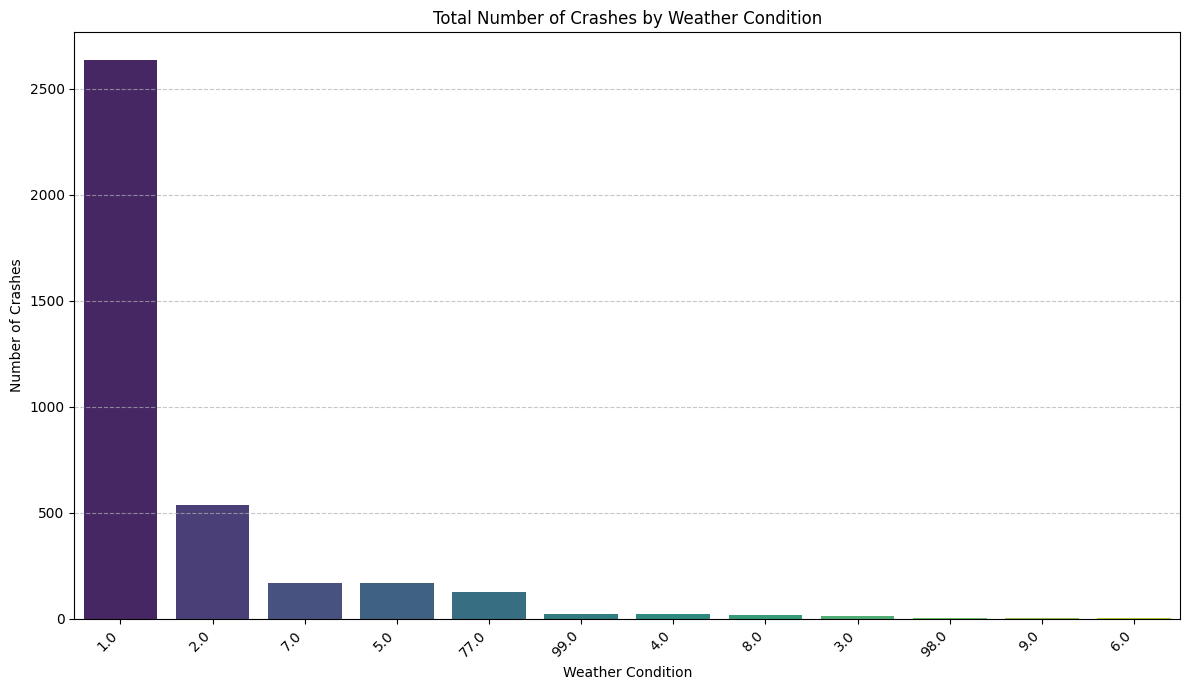

In [ ]:
print("Unique Weather Conditions and their Counts:")
print(df_merged['WEATHER'].value_counts())

# Plotting total crashes by weather condition
plt.figure(figsize=(12, 7))
sns.countplot(data=df_merged, x='WEATHER', palette='viridis', order=df_merged['WEATHER'].value_counts().index)
plt.title('Total Number of Crashes by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

,WEATHER,Daily_Crash_Count
0,7.0,2.965517
1,1.0,2.354781
2,5.0,1.931034
3,6.0,1.500000
4,2.0,1.414698
5,4.0,1.352941
6,8.0,1.307692
7,77.0,1.075630
8,3.0,1.071429
9,9.0,1.000000


/tmp/ipykernel_4740/120303304.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_crashes_per_weather, x='WEATHER', y='Daily_Crash_Count', palette='crest')


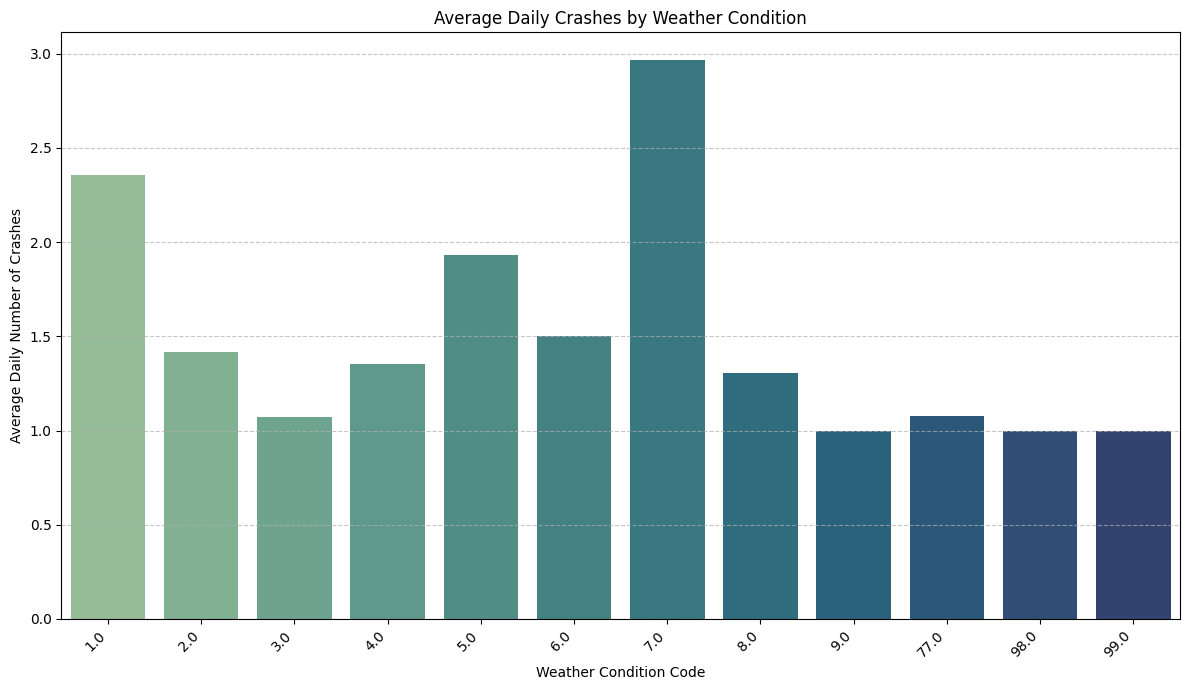

In [ ]:
# Calculate the daily crash count for each weather condition
daily_crashes_by_weather = df_merged.groupby(['CRASH_DATE', 'WEATHER']).size().reset_index(name='Daily_Crash_Count')

# Calculate the average daily crash count for each weather condition
average_crashes_per_weather = daily_crashes_by_weather.groupby('WEATHER')['Daily_Crash_Count'].mean().sort_values(ascending=False).reset_index()

display(average_crashes_per_weather)

# Plotting the average daily crashes by weather condition
plt.figure(figsize=(12, 7))
sns.barplot(data=average_crashes_per_weather, x='WEATHER', y='Daily_Crash_Count', palette='crest')
plt.title('Average Daily Crashes by Weather Condition')
plt.xlabel('Weather Condition Code')
plt.ylabel('Average Daily Number of Crashes')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()